# LeetCode #28: Find the Index of the First Occurrence in a String

https://leetcode.com/problems/find-the-index-of-the-first-occurrence-in-a-string/

## Comparison of Approaches

| Approach | Time | Space |
| :--- | :--- | :--- |
| **Brute Force** | $O(n \cdot m)$ | $O(1)$ |
| **KMP Algorithm** ★ | $O(n+m)$ | $O(m)$ |

---

## Understanding the Methods

### Brute Force
For each starting position $i$ in `haystack`, check if `haystack[i..i+m-1] == needle`. If a character mismatches, reset needle index to 0. Worst case $O(n \cdot m)$ for pathological inputs like haystack=`"aaaaab"`, needle=`"aaab"`.

### Optimal: KMP Algorithm ★
KMP uses a preprocessing step to build the **LPS (Longest Proper Prefix which is also Suffix)** table for the needle. During the search, when a mismatch occurs at position `j` in the needle, instead of resetting `j` to 0, we jump to `lps[j-1]`. This avoids rescanning characters we already know match, giving $O(n)$ search after $O(m)$ preprocessing.

**LPS table:** For needle `"AABAA"`, LPS = `[0, 1, 0, 1, 2]`. At position 4, `"AA"` is both a prefix and suffix of `"AABAA"`.

**Constraints:**
* $1 \leq$ haystack.length, needle.length $\leq 10^4$
* `haystack` and `needle` consist of only lowercase English characters

## Solutions

### C#

In [ ]:
public class Solution {
    public int StrStr(string haystack, string needle) {
        int n = haystack.Length, m = needle.Length;
        if (m == 0) return 0;
        int[] lps = BuildLPS(needle);
        int j = 0;
        for (int i = 0; i < n; i++) {
            while (j > 0 && haystack[i] != needle[j]) j = lps[j - 1];
            if (haystack[i] == needle[j]) j++;
            if (j == m) return i - m + 1;
        }
        return -1;
    }

    private int[] BuildLPS(string needle) {
        int m = needle.Length;
        int[] lps = new int[m];
        int len = 0;
        for (int i = 1; i < m; ) {
            if (needle[i] == needle[len])      { lps[i++] = ++len; }
            else if (len > 0)                  { len = lps[len - 1]; }
            else                               { lps[i++] = 0; }
        }
        return lps;
    }
}

### Python

In [ ]:
class Solution:
    def strStr(self, haystack: str, needle: str) -> int:
        n, m = len(haystack), len(needle)
        if m == 0:
            return 0
        lps = self._build_lps(needle)
        j = 0
        for i in range(n):
            while j > 0 and haystack[i] != needle[j]:
                j = lps[j - 1]
            if haystack[i] == needle[j]:
                j += 1
            if j == m:
                return i - m + 1
        return -1

    def _build_lps(self, needle: str) -> list:
        m = len(needle)
        lps = [0] * m
        length = 0
        i = 1
        while i < m:
            if needle[i] == needle[length]:
                length += 1
                lps[i] = length
                i += 1
            elif length > 0:
                length = lps[length - 1]
            else:
                lps[i] = 0
                i += 1
        return lps

### Go

In [ ]:
package main

func strStr(haystack string, needle string) int {
	n, m := len(haystack), len(needle)
	if m == 0 {
		return 0
	}
	lps := buildLPS(needle)
	j := 0
	for i := 0; i < n; i++ {
		for j > 0 && haystack[i] != needle[j] {
			j = lps[j-1]
		}
		if haystack[i] == needle[j] {
			j++
		}
		if j == m {
			return i - m + 1
		}
	}
	return -1
}

func buildLPS(needle string) []int {
	m := len(needle)
	lps := make([]int, m)
	l := 0
	for i := 1; i < m; {
		if needle[i] == needle[l] {
			l++
			lps[i] = l
			i++
		} else if l > 0 {
			l = lps[l-1]
		} else {
			lps[i] = 0
			i++
		}
	}
	return lps
}

### Rust

In [ ]:
pub struct Solution;

impl Solution {
    pub fn str_str(haystack: String, needle: String) -> i32 {
        let h: Vec<u8> = haystack.bytes().collect();
        let n: Vec<u8> = needle.bytes().collect();
        let (hn, m) = (h.len(), n.len());
        if m == 0 { return 0; }
        let lps = Self::build_lps(&n);
        let mut j = 0usize;
        for i in 0..hn {
            while j > 0 && h[i] != n[j] { j = lps[j - 1]; }
            if h[i] == n[j] { j += 1; }
            if j == m { return (i - m + 1) as i32; }
        }
        -1
    }

    fn build_lps(needle: &[u8]) -> Vec<usize> {
        let m = needle.len();
        let mut lps = vec![0usize; m];
        let mut len = 0usize;
        let mut i = 1;
        while i < m {
            if needle[i] == needle[len] {
                len += 1;
                lps[i] = len;
                i += 1;
            } else if len > 0 {
                len = lps[len - 1];
            } else {
                lps[i] = 0;
                i += 1;
            }
        }
        lps
    }
}

## Example Scenarios

### 1. Common Case — Match at the Beginning
**Input:** haystack = `"sadbutsad"`, needle = `"sad"`
KMP builds LPS = [0,0,0]. Scanning: s==s, a==a, d==d → j reaches m at i=2. Return i - m + 1 = 0.
**Why tricky:** Simple baseline — verifies the algorithm returns the *first* occurrence, not the last (index 6).

**Output:** `0`

### 2. Slightly Complex — Repeated Prefix (KMP Shines)
**Input:** haystack = `"aaaaab"`, needle = `"aaab"`
LPS for "aaab" = [0,1,2,0]. Brute force would retry from indices 1, 2, 3 — each failing at the last char. KMP uses the LPS to jump j backward without backtracking i: after mismatch at i=3/j=3, j drops to lps[2]=2, saving 2 comparisons.
**Why tricky:** Classic adversarial pattern for brute force. KMP reduces $O(n \cdot m)$ to $O(n + m)$ by leveraging prefix repetition.

**Output:** `2`

### 3. Edge Case: Time Factor — Match at Very End (n = 10⁴, m = 10³)
**Input:** haystack = `"aaa...aab"` (10⁴ 'a's then 'b'), needle = `"aaa...ab"` (999 'a's then 'b')
Brute force: each of $\approx 9000$ starting positions fails at the last character → $\approx 9 \times 10^6$ comparisons. KMP: $i$ never backtracks, total $\approx n + m \approx 1.1 \times 10^4$ comparisons.
**Why tricky:** This is the canonical worst case for brute force. Interviewers ask about it to verify you understand why KMP's "no backtrack on $i$" guarantee matters.

**Output:** `9001` — found at the very end, $O(n+m)$ with KMP.

### 4. Edge Case: Space Factor — No Match, Full LPS Built
**Input:** haystack = `"leetcode"`, needle = `"leeto"`
LPS for "leeto" = [0,0,0,0,0] (no repeating prefix). Match proceeds: l,e,e,t all match, then 'c' ≠ 'o' at j=4. j resets to lps[3]=0. No further match. LPS array of size $m$ is allocated but provides no skip benefit.
**Why tricky:** When the needle has all unique characters, the LPS array is all zeros — maximum $O(m)$ space consumption with zero skip benefit. Tests that space is allocated unconditionally.

**Output:** `-1`

### 5. Almost-Impossible but Plausible — Needle Equals Haystack
**Input:** haystack = `"abcde..."` (10⁴ chars), needle = identical string (10⁴ chars)
When $n = m$, every character matches. j reaches m exactly at i = m - 1. Return 0. Only one possible starting index exists.
**Why tricky:** $O(m)$ space for LPS + $O(n+m) = O(2n)$ time. Tests that the algorithm correctly returns 0 on a full-length match without attempting any further scanning past the match point.

**Output:** `0`

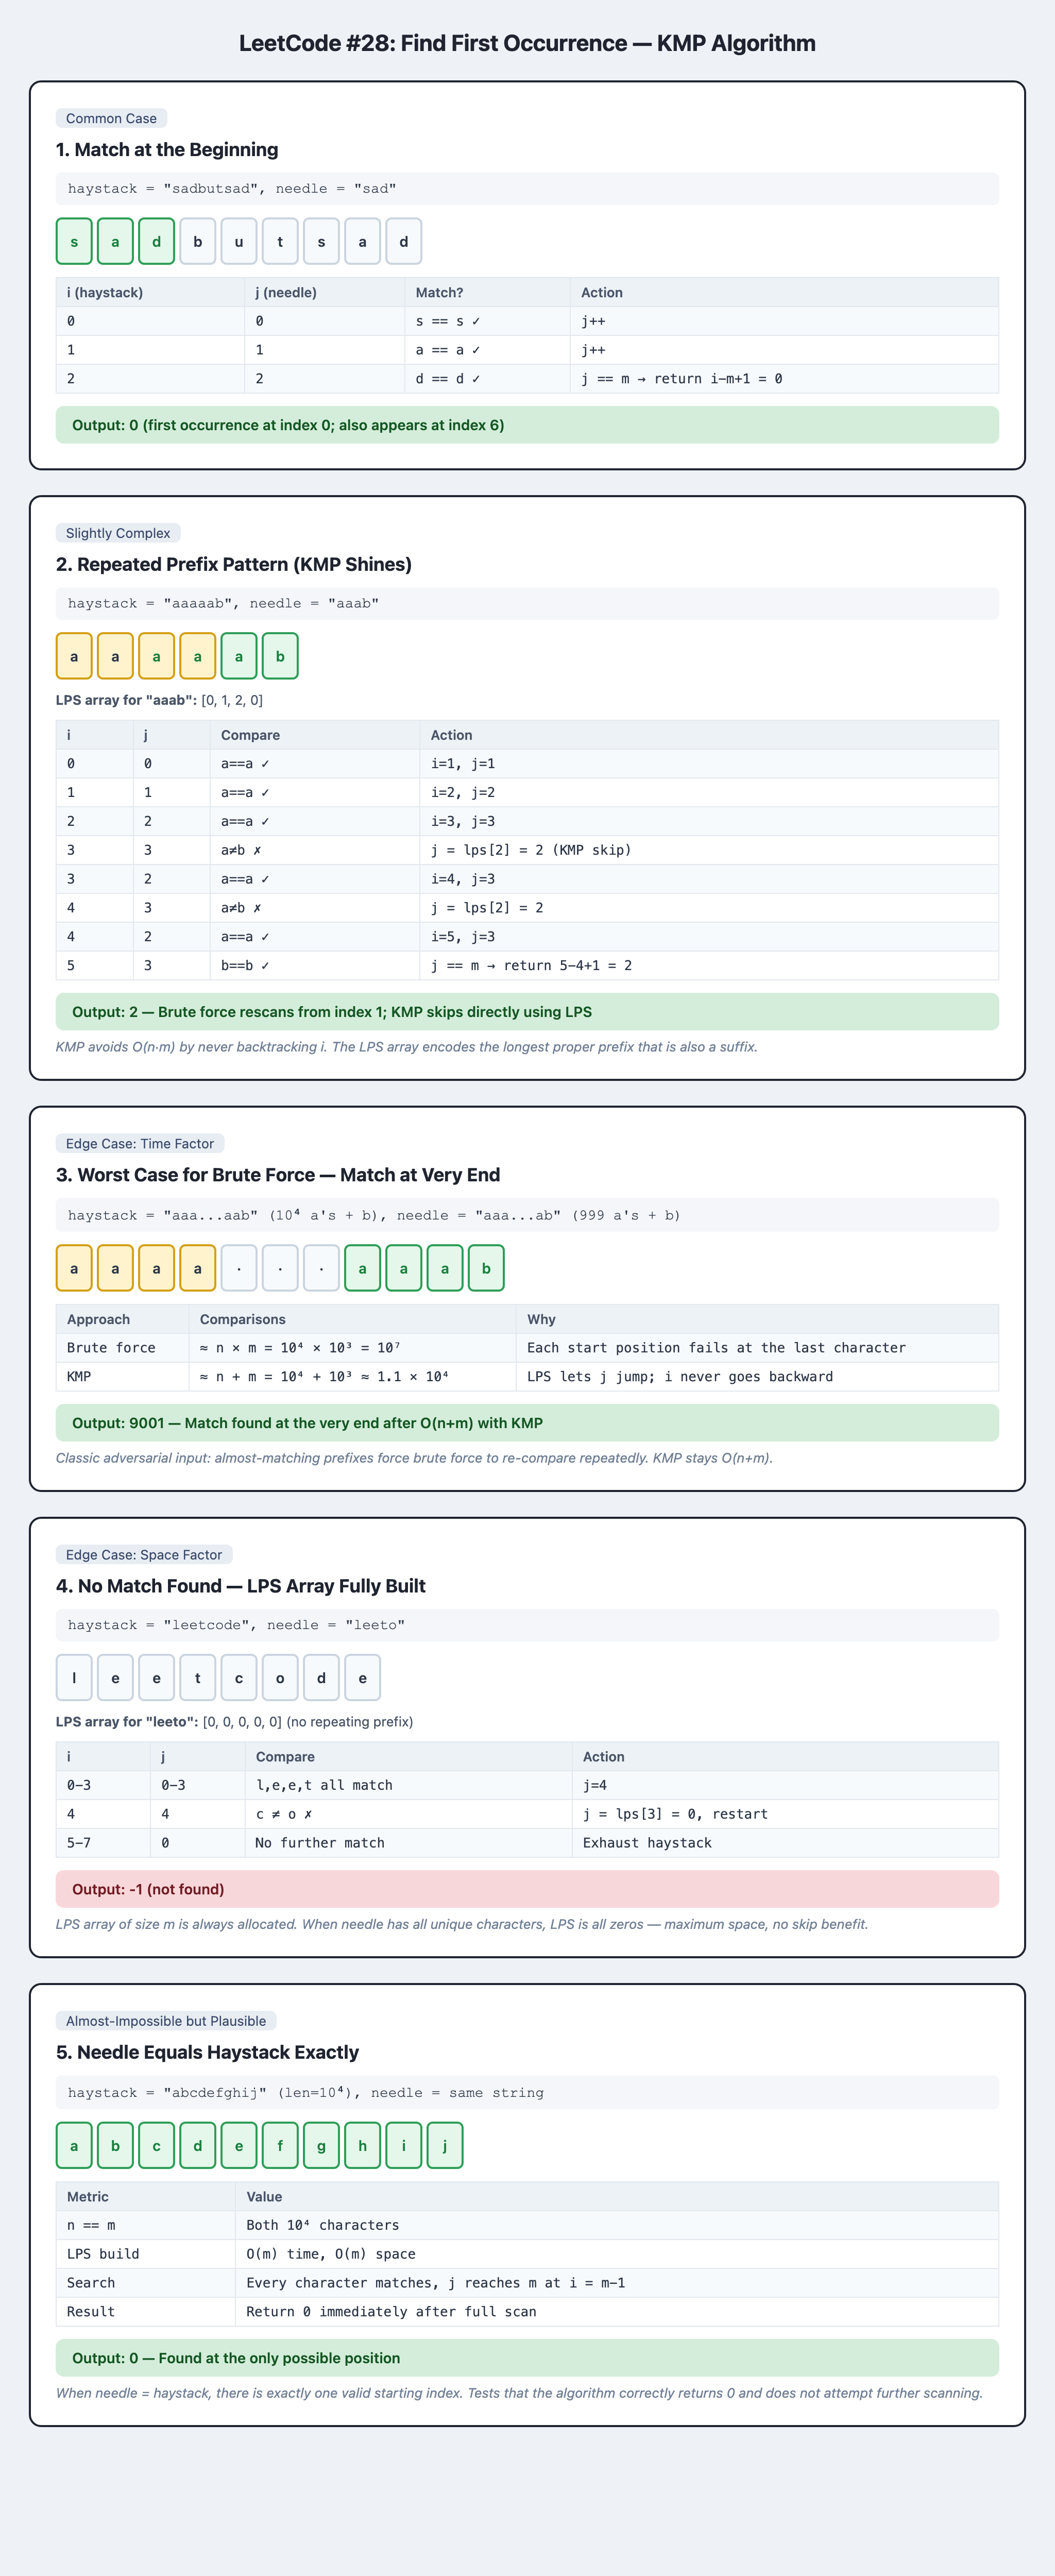